In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.decomposition import PCA

from google.colab import files

In [3]:
from google.colab import files
uploaded = files.upload()
train_df = pd.read_csv('train_data.csv')
test_df  = pd.read_csv('test_data.csv')

FEATURES = ['danceability','energy','valence','tempo',
            'acousticness','speechiness','loudness','instrumentalness']

X_train = train_df[FEATURES].values
y_train = train_df['mood'].values
X_test  = test_df[FEATURES].values
y_test  = test_df['mood'].values

print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Saving scaler.pkl to scaler.pkl
Saving label_encoder.pkl to label_encoder.pkl
Saving train_data.csv to train_data.csv
Saving test_data.csv to test_data.csv
Train: (30400, 8)  Test: (7600, 8)


In [4]:
models = {
    'k-NN':                KNeighborsClassifier(n_neighbors=7),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200,
                                                  max_depth=20,
                                                  random_state=42,
                                                  n_jobs=-1)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'f1':       f1_score(y_test, preds, average='weighted')
    }
    print(f"{name:25s}  Acc: {results[name]['accuracy']:.3f}  F1: {results[name]['f1']:.3f}")

k-NN                       Acc: 0.649  F1: 0.643
Logistic Regression        Acc: 0.615  F1: 0.614
Random Forest              Acc: 0.700  F1: 0.699


In [5]:
rf = models['Random Forest']
preds_rf = rf.predict(X_test)
print(classification_report(y_test, preds_rf,
      target_names=['Calm','Happy','Intense','Melancholic']))

              precision    recall  f1-score   support

        Calm       0.77      0.69      0.73      2000
       Happy       0.74      0.78      0.76      2200
     Intense       0.74      0.77      0.75      1800
 Melancholic       0.52      0.51      0.52      1600

    accuracy                           0.70      7600
   macro avg       0.69      0.69      0.69      7600
weighted avg       0.70      0.70      0.70      7600



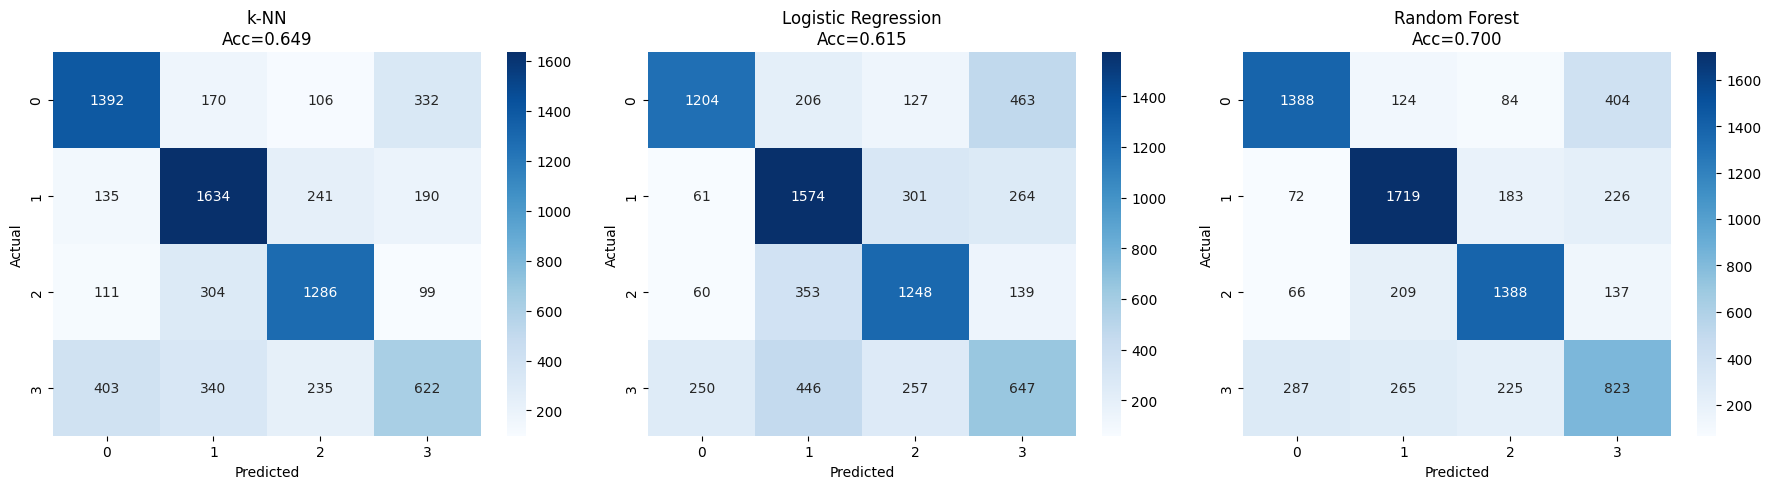

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
label_names = sorted(set(y_test))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds, labels=label_names)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(f'{name}\nAcc={accuracy_score(y_test,preds):.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

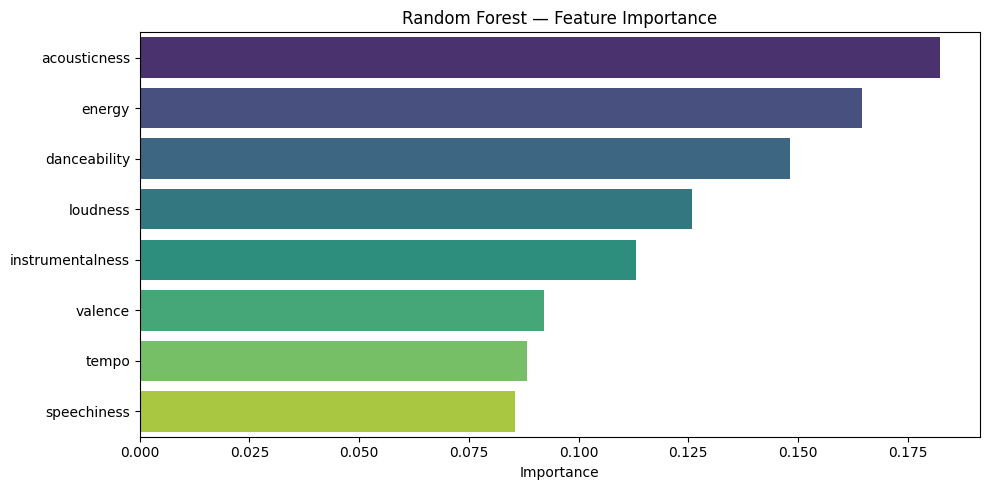

In [7]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=[FEATURES[i] for i in indices], palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Variance explained: 58.18%


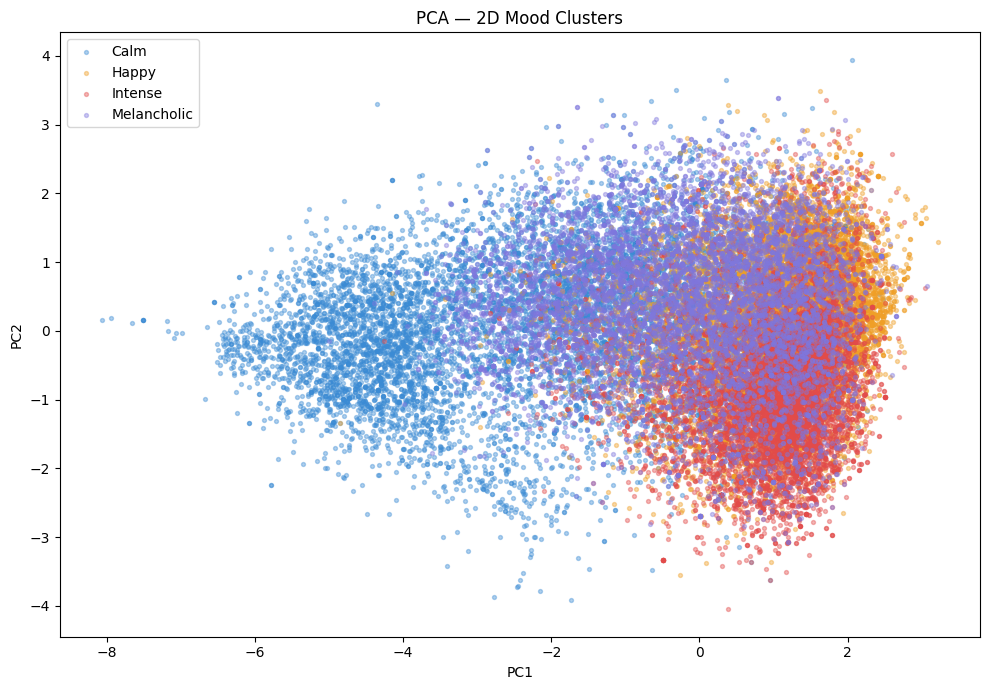

In [10]:
pca = PCA(n_components=2, random_state=42)
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

X_2d = pca.fit_transform(X_all)
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

mood_colors = {'Calm':'#3B8BD4', 'Happy':'#EF9F27',
               'Intense':'#E24B4A', 'Melancholic':'#7F77DD'}

label_idx = {'Calm':0, 'Happy':1, 'Intense':2, 'Melancholic':3}

plt.figure(figsize=(10, 7))
for mood, color in mood_colors.items():
    idx  = label_idx[mood]
    mask = y_all == idx
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=mood, alpha=0.4, s=8)

plt.legend()
plt.title('PCA — 2D Mood Clusters')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('pca_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
joblib.dump(rf,  'model.pkl')
joblib.dump(pca, 'pca.pkl')
print("Saved model.pkl and pca.pkl")

Saved model.pkl and pca.pkl


In [12]:
for fname in ['model.pkl','pca.pkl','confusion_matrices.png',
              'feature_importance.png','pca_plot.png']:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>